In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

In [2]:
gmt_path = Path('scarf_datasets/pbmc_signatures.gmt')
gmt_path.write_text(
    'T_cell\tna\tCD3D\tCD3E\tTRAC\tLTB\tIL7R\n'
    'B_cell\tna\tMS4A1\tCD79A\tCD37\tCD74\tHLA-DRA\n'
    'Myeloid\tna\tLST1\tS100A8\tS100A9\tCTSS\tFCER1G\n',
    encoding='utf-8',
)
gene_sets = scarf.read_gmt(gmt_path)
gene_sets

,source,target
0,T_cell,CD3D
1,T_cell,CD3E
2,T_cell,TRAC
3,T_cell,LTB
4,T_cell,IL7R
5,B_cell,MS4A1
6,B_cell,CD79A
7,B_cell,CD37
8,B_cell,CD74
9,B_cell,HLA-DRA


In [3]:
available = {str(name).upper() for name in ds.RNA.feats.fetch('names')}
(
    gene_sets.assign(
        matched=gene_sets['target'].str.upper().isin(available),
    )
    .groupby('source')['matched']
    .agg(['sum', 'count'])
)

,sum,count
source,,
B_cell,5,5
Myeloid,5,5
T_cell,5,5


In [4]:
weighted_sets = gene_sets.assign(weight=1.0)
weighted_sets.loc[
    weighted_sets['target'].isin(['S100A8', 'S100A9']),
    'weight',
] = 1.5
weighted_sets

,source,target,weight
0,T_cell,CD3D,1.0
1,T_cell,CD3E,1.0
2,T_cell,TRAC,1.0
3,T_cell,LTB,1.0
4,T_cell,IL7R,1.0
5,B_cell,MS4A1,1.0
6,B_cell,CD79A,1.0
7,B_cell,CD37,1.0
8,B_cell,CD74,1.0
9,B_cell,HLA-DRA,1.0


In [5]:
waggr = ds.run_waggr(
    weighted_sets,
    label='pbmc_waggr',
    mode='wmean',
    tmin=3,
    overwrite=True,
)
waggr_scores = pd.DataFrame(
    waggr.data.compute(),
    columns=list(waggr.source_names),
)
waggr_scores.describe().loc[['min', '50%', 'max']]

Writing waggr enrichment: 1 / 1 complete

Scoring WAGGR: 1 / 1 complete

,B_cell,Myeloid,T_cell
min,0.000000,0.000000,0.000000
50%,0.172662,0.042977,0.563025
max,7.278358,30.974056,2.551281


In [6]:
waggr_unweighted = ds.run_waggr(
    gene_sets.assign(weight=1.0),
    label='pbmc_waggr_unweighted',
    mode='wmean',
    tmin=3,
    overwrite=True,
)
unweighted_scores = pd.DataFrame(
    waggr_unweighted.data.compute(),
    columns=list(waggr_unweighted.source_names),
)
pd.DataFrame(
    {
        'weighted': waggr_scores['Myeloid'],
        'unweighted': unweighted_scores['Myeloid'],
    }
).describe().loc[['min', '50%', 'max']]

Writing waggr enrichment: 1 / 1 complete

Scoring WAGGR: 1 / 1 complete

,weighted,unweighted
min,0.000000,0.000000
50%,0.042977,0.047424
max,30.974056,25.161978


In [7]:
aucell = ds.run_aucell(
    gene_sets,
    label='pbmc_aucell',
    tmin=3,
    n_up=500,
    tie_seed=0,
    overwrite=True,
)
aucell_scores = pd.DataFrame(
    aucell.data.compute(),
    columns=list(aucell.source_names),
)
aucell_scores.describe().loc[['min', '50%', 'max']]

Writing aucell enrichment: 1 / 1 complete

Scoring AUCell: 1 / 1 complete

,B_cell,Myeloid,T_cell
min,0.000000,0.000000,0.000000
50%,0.129175,0.000000,0.424547
max,0.918310,0.952918,0.777867


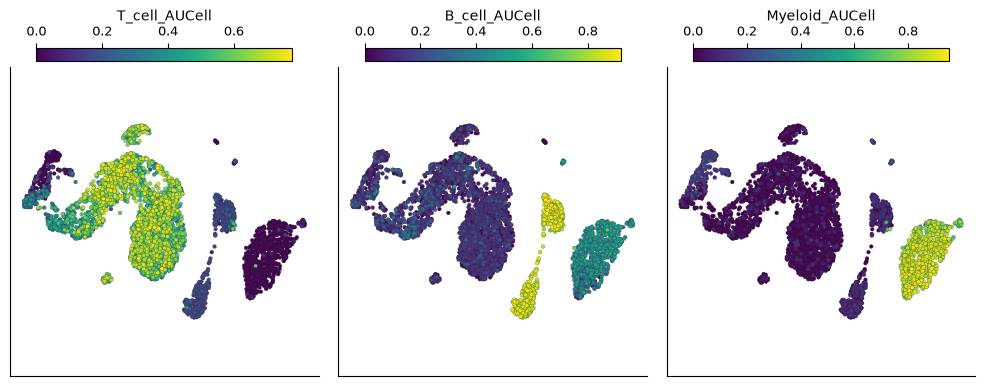

In [8]:
aucell_cols = []
for source in ['T_cell', 'B_cell', 'Myeloid']:
    result = ds.get_enrichment('pbmc_aucell', sources=[source])
    col = f'{source}_AUCell'
    ds.cells.insert(
        col,
        result.data.compute().ravel(),
        key=result.cell_key,
        overwrite=True,
    )
    aucell_cols.append(col)

present = [c for c in aucell_cols if c in ds.cells.columns]
if present:
    ds.plots.embedding(
        layout_key='RNA_UMAP',
        color_by=present,
        n_columns=3,
        sort_values=True,
    )

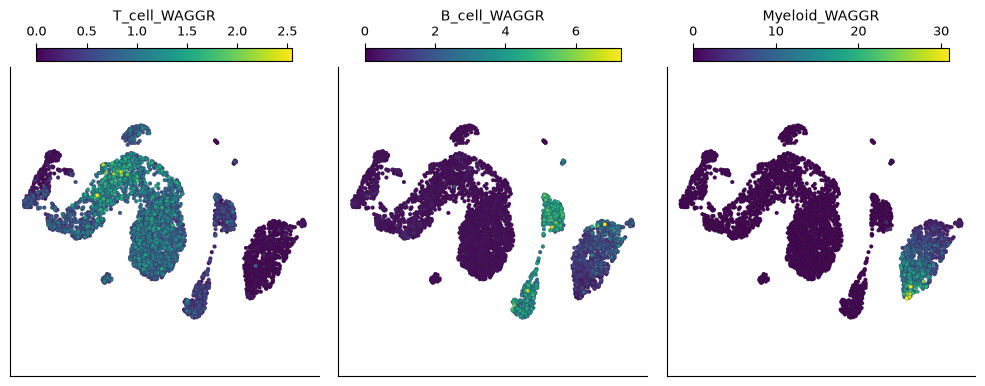

In [9]:
waggr_cols = []
for source in ['T_cell', 'B_cell', 'Myeloid']:
    result = ds.get_enrichment('pbmc_waggr', sources=[source])
    col = f'{source}_WAGGR'
    ds.cells.insert(
        col,
        result.data.compute().ravel(),
        key=result.cell_key,
        overwrite=True,
    )
    waggr_cols.append(col)

present = [c for c in waggr_cols if c in ds.cells.columns]
if present:
    ds.plots.embedding(
        layout_key='RNA_UMAP',
        color_by=present,
        n_columns=3,
        sort_values=True,
    )

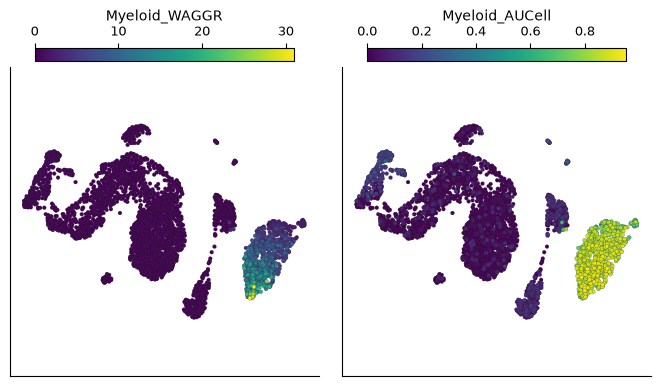

In [10]:
compare = [
    c for c in ['Myeloid_WAGGR', 'Myeloid_AUCell'] if c in ds.cells.columns
]
if len(compare) == 2:
    ds.plots.embedding(
        layout_key='RNA_UMAP',
        color_by=compare,
        n_columns=2,
        sort_values=True,
    )

In [11]:
myeloid_compare = ds.cells.to_pandas_dataframe(
    ['Myeloid_WAGGR', 'Myeloid_AUCell'],
    key='I',
)
myeloid_compare.describe()

,Myeloid_WAGGR,Myeloid_AUCell
count,3940.000000,3940.000000
mean,1.453040,0.168171
std,3.650681,0.312799
min,0.000000,0.000000
25%,0.019388,0.000000
50%,0.042977,0.000000
75%,0.121820,0.111871
max,30.974056,0.952918


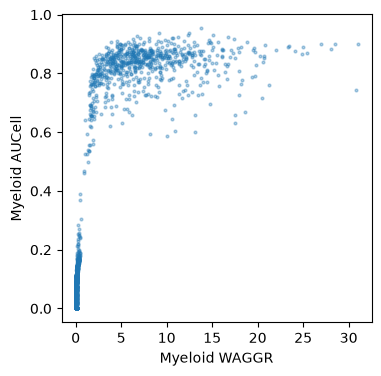

In [12]:
figure, axis = plt.subplots(figsize=(4, 4))
axis.scatter(
    myeloid_compare['Myeloid_WAGGR'],
    myeloid_compare['Myeloid_AUCell'],
    s=4,
    alpha=0.35,
)
axis.set_xlabel('Myeloid WAGGR')
axis.set_ylabel('Myeloid AUCell')
plt.show()